# **Airline Analyze**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
data = pd.read_csv(r'airlines_flights_data.csv')
data.head()

,index,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [8]:
data.drop(columns='index',inplace=True)

In [9]:
data.head()

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [5]:
data.shape

(300153, 11)

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 300153 entries, 0 to 300152
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           300153 non-null  object 
 1   flight            300153 non-null  object 
 2   source_city       300153 non-null  object 
 3   departure_time    300153 non-null  object 
 4   stops             300153 non-null  object 
 5   arrival_time      300153 non-null  object 
 6   destination_city  300153 non-null  object 
 7   class             300153 non-null  object 
 8   duration          300153 non-null  float64
 9   days_left         300153 non-null  int64  
 10  price             300153 non-null  int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 27.5+ MB


In [10]:
data.describe()

,duration,days_left,price
count,300153.000000,300153.000000,300153.000000
mean,12.221021,26.004751,20889.660523
std,7.191997,13.561004,22697.767366
min,0.830000,1.000000,1105.000000
25%,6.830000,15.000000,4783.000000
50%,11.250000,26.000000,7425.000000
75%,16.170000,38.000000,42521.000000
max,49.830000,49.000000,123071.000000


In [11]:
data.isnull().sum()

airline             0
flight              0
source_city         0
departure_time      0
stops               0
arrival_time        0
destination_city    0
class               0
duration            0
days_left           0
price               0
dtype: int64

# Questions

1. **What are the airlines in the dataset, and their frequencies?**

In [13]:
data["airline"].value_counts()

airline
Vistara      127859
Air_India     80892
Indigo        43120
GO_FIRST      23173
AirAsia       16098
SpiceJet       9011
Name: count, dtype: int64

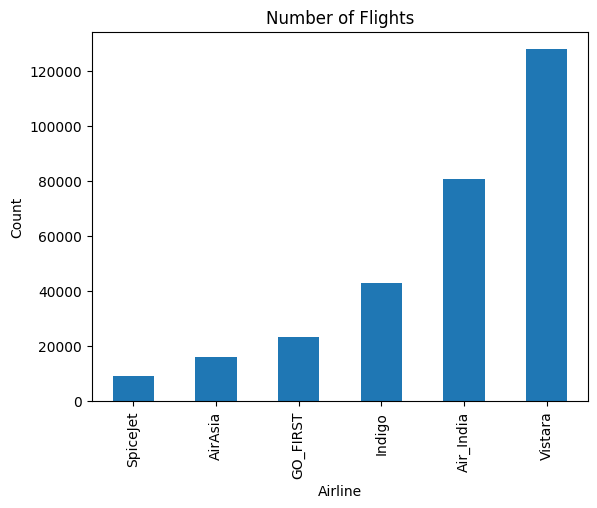

In [16]:
data['airline'].value_counts(ascending=True).plot(kind='bar')
plt.title('Number of Flights')
plt.xlabel("Airline")
plt.ylabel("Count")
plt.savefig("Figures/Number_of_flights.png")
plt.show()

2. **Bar Graph**: Departure Time distribution.

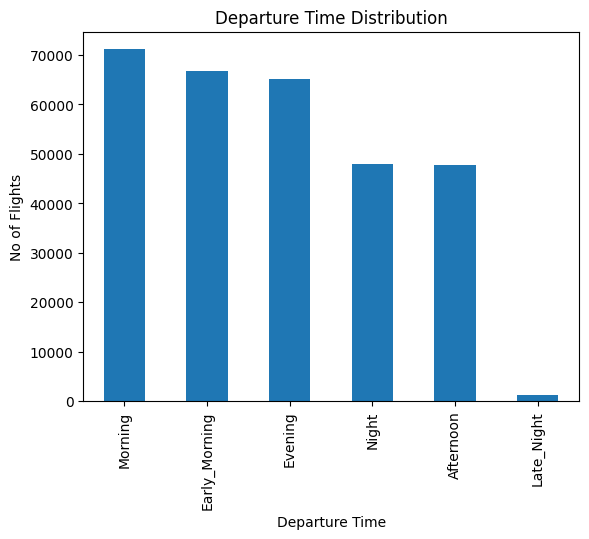

In [19]:
data["departure_time"].value_counts().plot.bar()
plt.xlabel("Departure Time")
plt.ylabel("No of Flights")
plt.title("Departure Time Distribution")
plt.savefig("Departure_time_distribution.png")
plt.show()

3. **Bar Graph**: Arrival Time distribution.


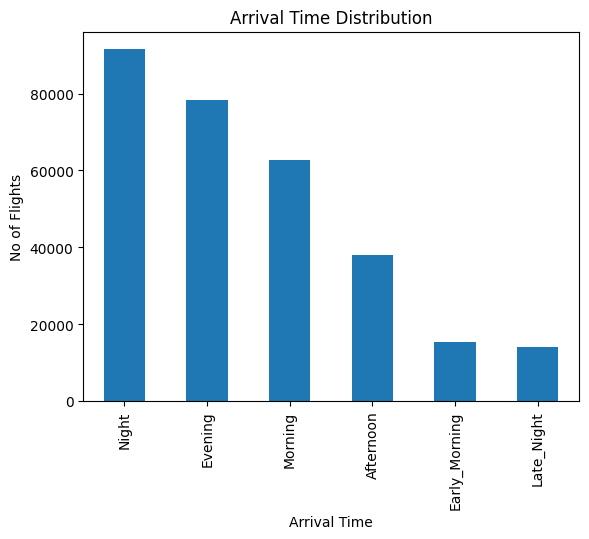

In [20]:
data["arrival_time"].value_counts().plot.bar()
plt.xlabel("Arrival Time")
plt.ylabel("No of Flights")
plt.title("Arrival Time Distribution")
plt.savefig("Arrival_time_distribution.png")
plt.show()

4. **Bar Graph**: Source City distribution.


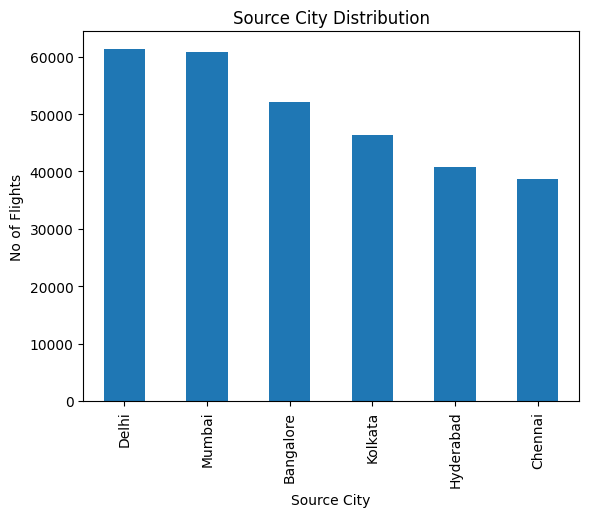

In [22]:
data["source_city"].value_counts().plot.bar()
plt.xlabel("Source City")
plt.ylabel("No of Flights")
plt.title("Source City Distribution")
plt.savefig("Source_city_distribution.png")
plt.show()

5. **Bar Graph**: Destination City distribution.


In [23]:
data.head()

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


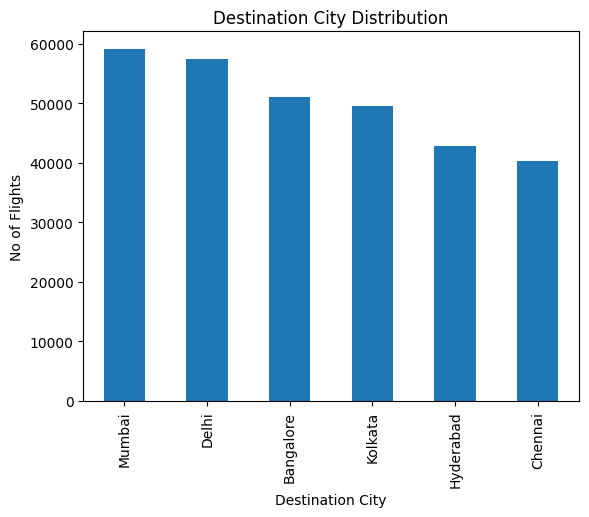

In [25]:
data["destination_city"].value_counts().plot.bar()
plt.xlabel("Destination City")
plt.ylabel("No of Flights")
plt.title("Destination City Distribution")
plt.savefig("Destination_city_distribution.png")
plt.show()

6. Does ticket **price vary with airlines**?


In [26]:
data.groupby('airline')['price'].mean()

airline
AirAsia       4091.072742
Air_India    23507.019112
GO_FIRST      5652.007595
Indigo        5324.216303
SpiceJet      6179.278881
Vistara      30396.536302
Name: price, dtype: float64

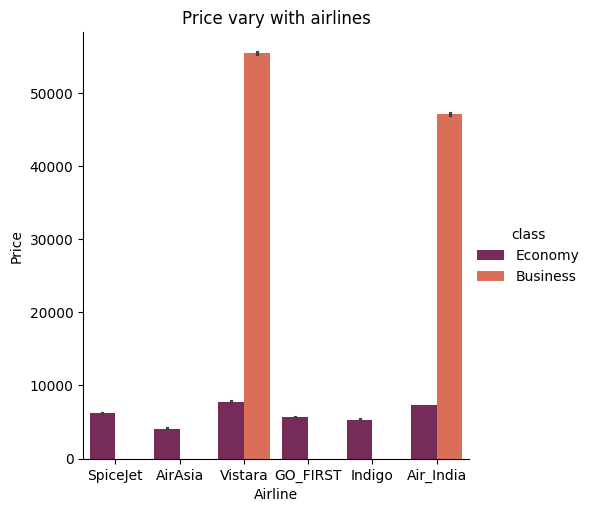

In [55]:
sns.catplot(x='airline',y='price',kind='bar',palette='rocket',hue='class',data=data)
plt.xlabel("Airline")
plt.ylabel("Price")
plt.title("Price vary with airlines")
plt.savefig("Figures/Price_vary_with_airline.png")
plt.show()

7. Does ticket **price change based on departure & arrival times**?


In [30]:
data.groupby('departure_time')['price'].mean()

departure_time
Afternoon        18179.203331
Early_Morning    20370.676718
Evening          21232.361894
Late_Night        9295.299387
Morning          21630.760254
Night            23062.146808
Name: price, dtype: float64

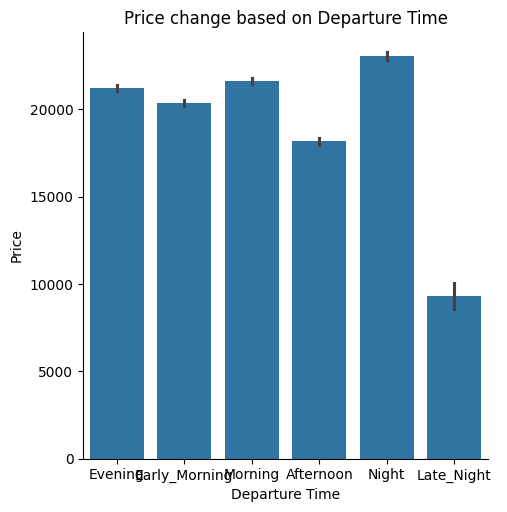

In [56]:
sns.catplot(x='departure_time',y='price',kind='bar',data=data)
plt.xlabel("Departure Time")
plt.ylabel("Price")
plt.title("Price change based on Departure Time")
plt.savefig("Figures/price_change_based_on_departure_time.png")
plt.show()

In [31]:
data.groupby('arrival_time')['price'].mean()

arrival_time
Afternoon        18494.598993
Early_Morning    14993.139521
Evening          23044.371615
Late_Night       11284.906078
Morning          22231.076098
Night            21586.758341
Name: price, dtype: float64

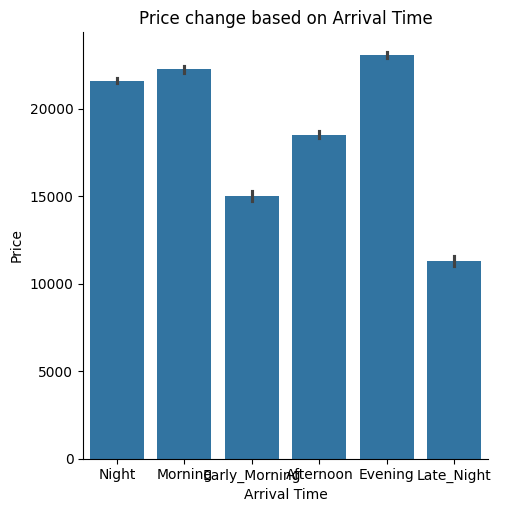

In [57]:
sns.catplot(x='arrival_time',y='price',kind='bar',data=data)
plt.xlabel("Arrival Time")
plt.ylabel("Price")
plt.title("Price change based on Arrival Time")
plt.savefig("Figures/price_change_based_on_arrival_time.png")
plt.show()

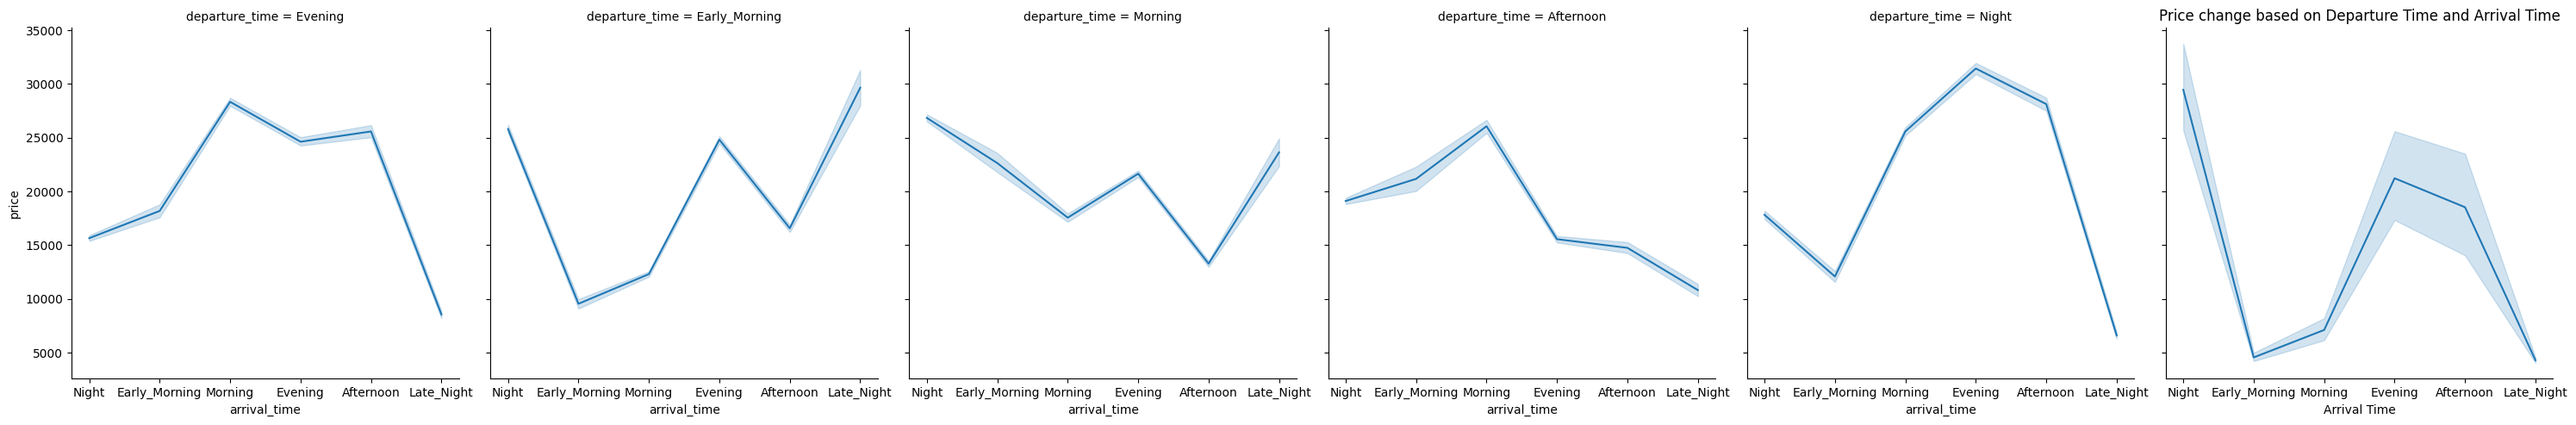

In [58]:
sns.relplot(x='arrival_time',y='price',kind='line',data=data,col = 'departure_time')
plt.xlabel("Arrival Time")
plt.ylabel("Price")
plt.title("Price change based on Departure Time and Arrival Time")
plt.savefig("Figures/price_change_based_on_departure_time_and_arrival_time.png")
plt.show()

8. How does **price change with Source & Destination**?


In [37]:
data.columns

Index(['airline', 'flight', 'source_city', 'departure_time', 'stops',
       'arrival_time', 'destination_city', 'class', 'duration', 'days_left',
       'price'],
      dtype='object')

In [38]:
data.groupby('source_city')['price'].mean()

source_city
Bangalore    21469.460575
Chennai      21995.339871
Delhi        18951.326639
Hyderabad    20155.623879
Kolkata      21746.235679
Mumbai       21483.818839
Name: price, dtype: float64

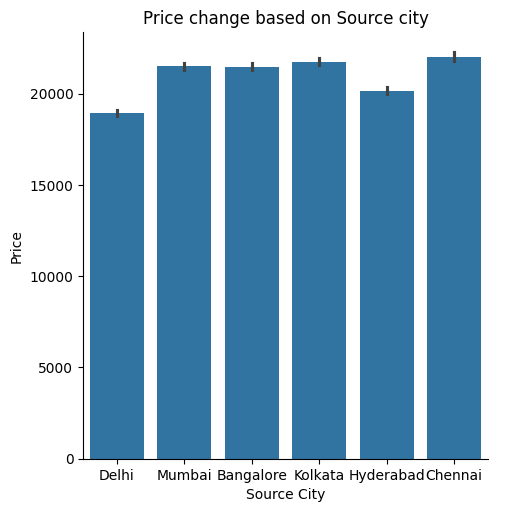

In [59]:
sns.catplot(x='source_city',y='price',kind='bar',data=data)
plt.xlabel("Source City")
plt.ylabel("Price")
plt.title("Price change based on Source city")
plt.savefig("Figures/price_change_based_on_source_city.png")
plt.show()

In [40]:
data.groupby('destination_city')['price'].mean()

destination_city
Bangalore    21593.955784
Chennai      21953.323969
Delhi        18436.767870
Hyderabad    20427.661284
Kolkata      21959.557556
Mumbai       21372.529469
Name: price, dtype: float64

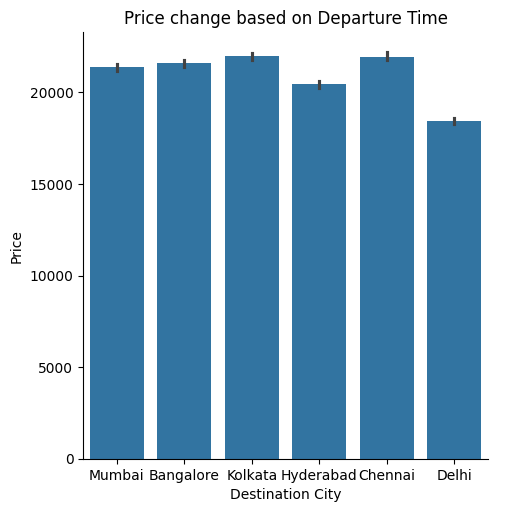

In [60]:
sns.catplot(x='destination_city',y='price',kind='bar',data=data)
plt.xlabel("Destination City")
plt.ylabel("Price")
plt.title("Price change based on Departure Time")
plt.savefig("Figures/price_change_based_on_destination_city.png")
plt.show()

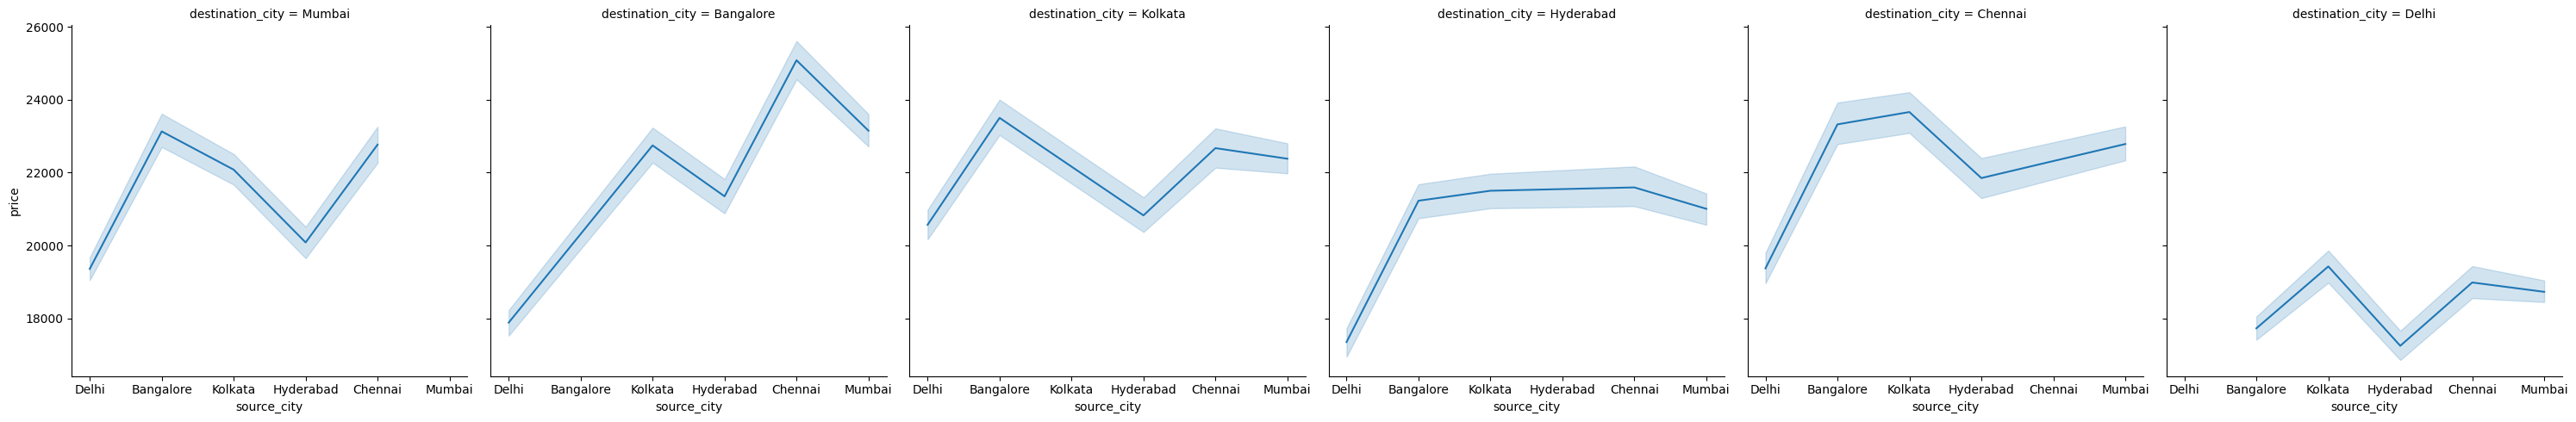

In [42]:
sns.relplot(x='source_city',y='price',kind='line',data=data,col = 'destination_city')
plt.show()

9. How is the price affected when tickets are bought **1–2 days before departure**?


In [43]:
data['days_left'].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49])

In [45]:
data.groupby('days_left')['price'].mean().head(2)

days_left
1    21591.867151
2    30211.299801
Name: price, dtype: float64

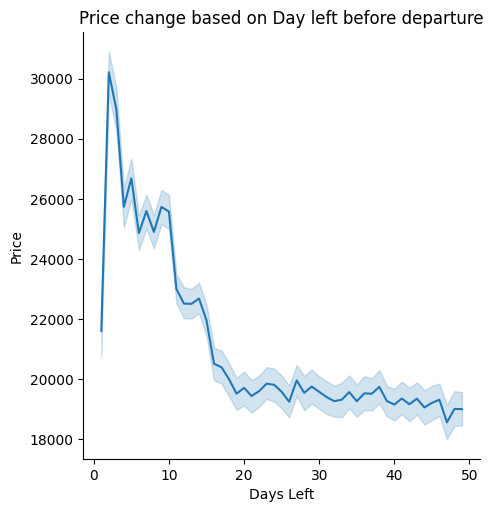

In [62]:
sns.relplot(x='days_left',y='price',kind='line',data=data)
plt.xlabel("Days Left")
plt.ylabel("Price")
plt.title("Price change based on Day left before departure")
plt.savefig("Figures/price_change_based_on_days_left.png")
plt.show()

10. How does the **ticket price vary between Economy and Business class**?


In [47]:
data['class'].unique()

array(['Economy', 'Business'], dtype=object)

In [50]:
x = data[data['class'] == 'Economy']
x['price'].mean()

np.float64(6572.342383362527)

In [51]:
y = data[data['class'] == 'Business']
y['price'].mean()

np.float64(52540.08112357868)

11. What is the **average price** of a **Vistara** flight from **Delhi to Hyderabad** in **Business Class**?


In [54]:
data[(data['airline']=='Vistara') & (data['source_city']=="Delhi") & (data['destination_city']=="Hyderabad") & (data['class']=="Business")]['price'].mean()

np.float64(47939.840361445786)